In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.magnus as magnus

While the main purpose of Mag$\nu$s is to compute neutrino oscillation probabilities, at its core, it is an efficient implementation of the Magnus expansion of the matrix exponential whose computation is required to compute the time-evolution operator for any given Hamiltonian, including time-dependent (or position-dependent) ones.  Therefore, we can use Mag$\nu$s to compute the Magnus expansion of the matrix exponential
\begin{equation}
 U = \exp\left( \int_{t_i}^{t_f} A(t) dt \right)
\end{equation}
where $A$ is an arbitary $N \times N$ square matrix.  The Magnus expansion of the exponential is
\begin{equation}
 U = \exp\left( \Omega(t_i, t_f) \right) \;,
\end{equation}
where $\Omega$ is the series expansion
\begin{equation}
 \Omega(t_i, t_f) = \sum_{k=1}^{\infty} \Omega_k(t_i, t_f) \;,
\end{equation}
where the terms $\Omega_k$ of the expansion are computed recursively in terms of lower-order terms (see Wikipedia entry).  Mag$\nu$s can return the terms $\Omega_k$ and also the matrix exponential, $U$.  The present version of the code implements calculation up to $k = 6$ term.

First, define a sample $3 \times 3$ complex matrix (unlike the Hamiltonian in the case of neutrino oscillations, it does not have to be Hermitian).

In [2]:
def A3(t):
    # return np.array([[1+1j*t, 2/(1+t), 3j*t], [0, 4-1j*t, 5+3j*t], [-3j*np.sqrt(t), -2j*(1/(1+t)), 1]], dtype=np.complex128)
    return np.array([[1+1j*t, 2*t*2, 3j*t], [0, 4-1j*t, 5+3j*t], [-3j*np.sqrt(t), -2j*t, 1]], dtype=np.complex128)

t_i, t_f = 0, 1 # Initial and final times of the matrix integral

The terms $\Omega_k$ of the expansion have the same dimensions as the input matrix $A_3$ (in this case, $3 \times 3$).  To get at the individual $\Omega_k$ rather than just their exponentiated sum, pass `return_magnus_terms=True` to `magnus_expansion`; it then returns the pair `(exp_Omega, Omega_terms)`.

By default the matrix integral is evaluated on a grid of `n_tpts = 50` points, spaced *linearly* between $t_i$ and $t_f$, and the expansion is truncated at `order = 2`.

One caveat matters here.  The default integration method is `'gl'` (Gauss-Legendre), which is *commutator-free*: it never forms the individual $\Omega_k$ at all, and so returns only their combined effect, no matter what `order` you ask for.  Because this section is specifically about the term-by-term structure of the series, we ask for `'trapezoid'`, which does build each term explicitly.

In [3]:
# 'trapezoid' (not the default 'gl') so that the individual terms actually exist
_, (Omega_1, Omega_2) = magnus.magnus_expansion(A3, t_i, t_f, order=2,
                                                integration_method='trapezoid',
                                                return_magnus_terms=True)
print(Omega_1) # The first-order term is just what we would compute were A3 time-independent
print(Omega_2) # The second-order term is the first correction to that

[[1.+0.5j        2.+0.j         0.+1.5j       ]
 [0.+0.j         4.-0.5j        5.+1.5j       ]
 [0.-1.99823381j 0.-1.j         1.+0.j        ]]
[[ 2.13039123e-01+0.00000000e+00j  1.00020825e+00+0.00000000e+00j
   1.66701374e+00+2.04557973e-16j]
 [ 2.13039123e-01+1.00439272e+00j -1.17819586e-16+8.33506872e-01j
   5.21125093e-17-1.16690962e+00j]
 [-7.10130410e-02+0.00000000e+00j  0.00000000e+00-2.16051959e-01j
  -2.13039123e-01-8.33506872e-01j]]


/tmp/ipykernel_295365/2786535803.py:2: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  _, (Omega_1, Omega_2) = magnus.magnus_expansion(A3, t_i, t_f, order=2,


Now compute terms up to $k = 6$, use a finer grid of 100 points to integrate, and switch from trapezoidal integration to integration via Simpson's rule.

In [4]:
_, Omega = magnus.magnus_expansion(A3, t_i, t_f, n_tpts=100, order=6,
                                   integration_method='simpson',
                                   return_magnus_terms=True)
for k, Omega_k in enumerate(Omega):
    print(r'Omega_'+str(k+1)+' = ')
    print(Omega_k)

Omega_1 = 
[[1.+0.5j        2.+0.j         0.+1.5j       ]
 [0.+0.j         4.-0.5j        5.+1.5j       ]
 [0.-1.99975275j 0.-1.j         1.+0.j        ]]
Omega_2 = 
[[ 2.14100246e-01+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
   1.66666667e+00-1.14386615e-16j]
 [ 2.14100246e-01+1.00062030e+00j  8.67244922e-17+8.33333333e-01j
   6.20902506e-15-1.16666667e+00j]
 [-7.13667487e-02+0.00000000e+00j  0.00000000e+00-2.14533005e-01j
  -2.14100246e-01-8.33333333e-01j]]
Omega_3 = 
[[ 0.03240569+0.43675729j  0.01018862+0.43333336j  0.12500001-0.34860856j]
 [ 0.25417537+0.04743653j  0.12685529-0.28612864j  0.40626316-0.04860854j]
 [ 0.22242935-0.04200309j  0.19166668-0.11144089j -0.15926098-0.15062865j]]
Omega_4 = 
[[-0.19621276+0.03915757j -0.17966682+0.46049227j -0.45427462+0.75436524j]
 [-0.87357296-0.09228325j -0.31468403+0.14953691j  0.15481874+0.61269894j]
 [-0.21734469+0.10147657j  0.02303048-0.1972591j   0.51089679-0.18869448j]]
Omega_5 = 
[[-0.48176865-0.22679936j -0.21042763-0.0389

/tmp/ipykernel_295365/3048630952.py:1: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  _, Omega = magnus.magnus_expansion(A3, t_i, t_f, n_tpts=100, order=6,


To compute the matrix exponential $\exp(\Omega)$, we do not need to compute the Magnus terms separately first.  We can directly call the `magnus_expansion` function, which does it internally.

In [5]:
exp_Omega = magnus.magnus_expansion(A3, t_i, t_f)
print(exp_Omega)

[[  2.86535029 -37.7565135j   38.44111627 -73.6438331j
   89.27077921 -34.62263996j]
 [-40.51715309 -72.35586486j -19.64332117-168.41070072j
  116.20401958-158.00820959j]
 [-29.77346021  -5.05906379j -58.22334689 -34.71614579j
  -23.25229071 -73.05782807j]]


/tmp/ipykernel_295365/2502095448.py:1: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  exp_Omega = magnus.magnus_expansion(A3, t_i, t_f)


And, like before, we can change the order of the expansion, the number of points used in the integration grid, and the integration method.

In [6]:
exp_Omega = magnus.magnus_expansion(A3, t_i, t_f, n_tpts=100, order=6, integration_method='simpson')
print(exp_Omega)

[[  0.44236679 -61.8992086j  105.30455007-112.62085169j
  175.54230239 -91.6036411j ]
 [-57.98959263 -75.11575181j  21.35226973-227.24038902j
  125.16472014-266.4840807j ]
 [-53.46549672 -10.36165561j -82.40106445-108.10730412j
  -52.65756319-165.40083505j]]


/tmp/ipykernel_295365/3498637149.py:1: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  exp_Omega = magnus.magnus_expansion(A3, t_i, t_f, n_tpts=100, order=6, integration_method='simpson')


Naturally, the more terms in the Magnus expansion and the finer the integration grid, the more accurate the returned matrix exponential is.  To illustrate this, let's plot the value of the real part of the $U_{11}$ component (i.e., of `exp_Omega[0][0]`) for different choices. 

In [7]:
# Generate the data
n_tpts_min, n_tpts_max = 2, 10
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
exp_Omega_elem_sel = [[magnus.magnus_expansion(A3, t_i, t_f, n_tpts=n, order=o+1, 
                                              integration_method='trapezoid')[elem_sel_i][elem_sel_j].real 
                      for n in range(n_tpts_min, n_tpts_max+1)] for o in range(order_max)]
exp_Omega_elem_sel = np.array(exp_Omega_elem_sel)

/tmp/ipykernel_295365/1074971294.py:5: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  exp_Omega_elem_sel = [[magnus.magnus_expansion(A3, t_i, t_f, n_tpts=n, order=o+1,


Text(0, 0.5, '$\\epsilon_{\\rm rel}$ vs.~$k=6$')

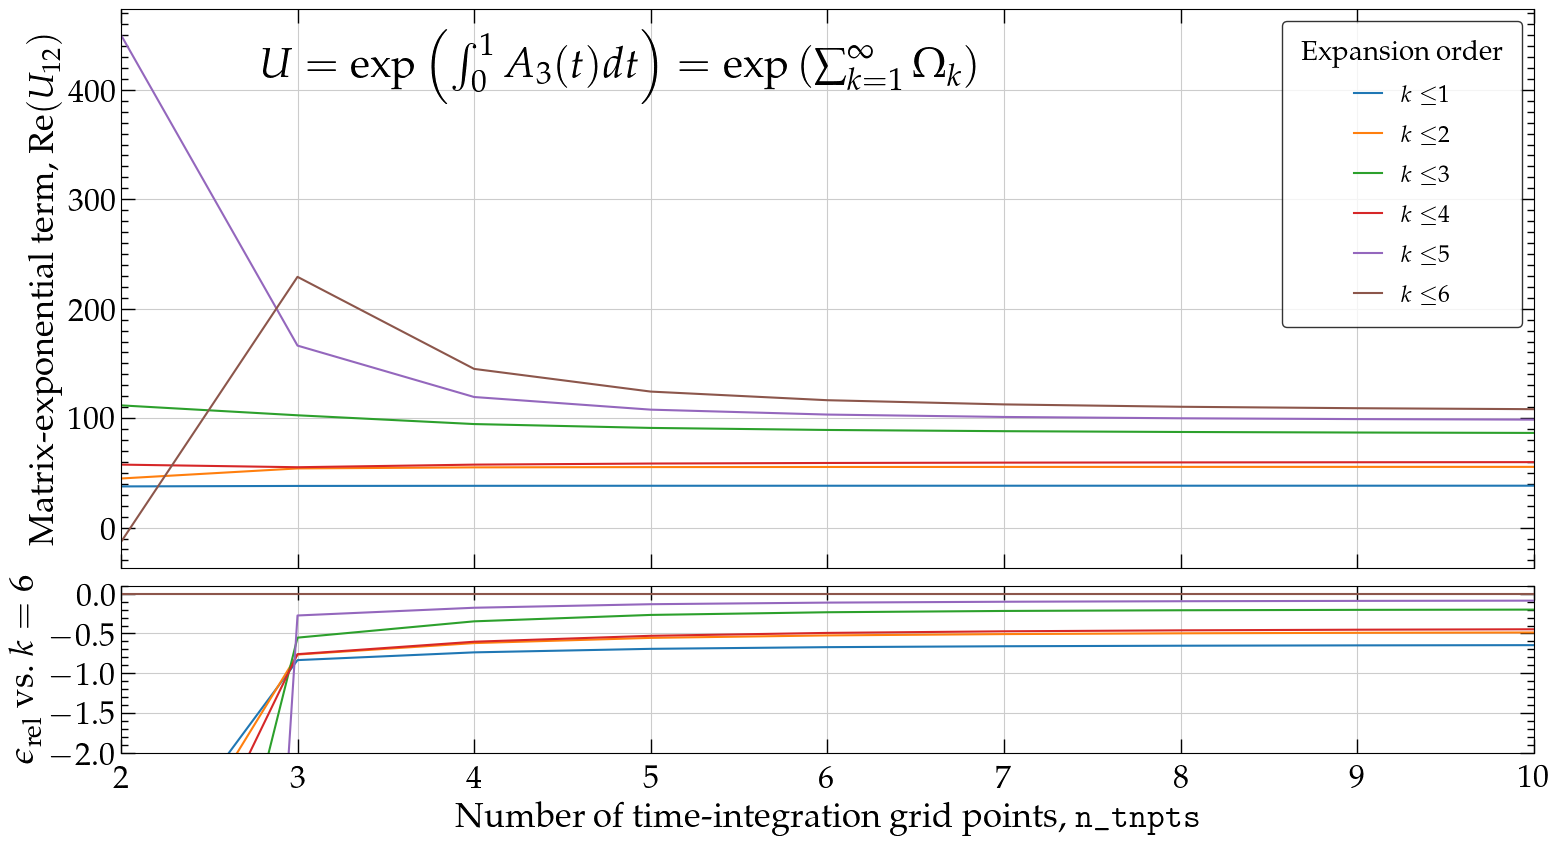

In [8]:
# Open the figure
heights, widths = [1.0, 0.3], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Plot data
n_tpts = range(n_tpts_min, n_tpts_max+1)
for order in range(order_max):
    ax[0].plot(n_tpts, exp_Omega_elem_sel[order], label=r'$k \leq $'+str(order+1))
    rel_error = (exp_Omega_elem_sel[order]-exp_Omega_elem_sel[order_max-1])/exp_Omega_elem_sel[order_max-1]
    ax[1].plot(n_tpts, rel_error)

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Expansion order')

# Annotate
ax[0].annotate(r'$U = \exp \left( \int_0^1 A_3(t) dt \right) = \exp \left( \sum_{k=1}^\infty \Omega_k \right) $', 
               xy = (0.10, 0.88),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(n_tpts_min, n_tpts_max)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
ax[1].set_ylim(-2, 0.1)
ax[0].xaxis.set_ticklabels([])
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=100))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=10))
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.5))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.1))
ax[0].set_ylabel(r'Matrix-exponential term, ${\rm Re} (U_{12})$')
ax[1].set_xlabel(r'Number of time-integration grid points, \texttt{n_tnpts}')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}$ vs.~$k=6$')

# Save plot
# filename = 'magnus_expansion_performance_vs_n_tnpts'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

This shows that, at least for short time intervals, like $t_i = 0$ to $t_f = 1$, it is enough to sue `n_tnpts = 10` points in the integration grid, and expansion up to $k = 6$.

However, because the Magnus expansion involves calculating exponential, it can result in an overflow if its argument is too large, i.e., if $t_f - t_f \gg 1$.  In this case, we partition the interval $[t_i, t_f]$ into multiple, smaller subintervals, compute the matrix exponential in each via Magnus expansion, and then compute their time-ordered product.  (This is actually the strategy adopted by Mag$\nu$s to compute neutrino oscillation probabilities.)

order = 1


/tmp/ipykernel_295365/2933112945.py:36: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, subint[0], subint[1], n_tpts=10, order=order+1,


order = 2


order = 3


order = 4


order = 5


order = 6


Text(0, 0.5, '$\\epsilon_{\\rm rel}$ vs. best')

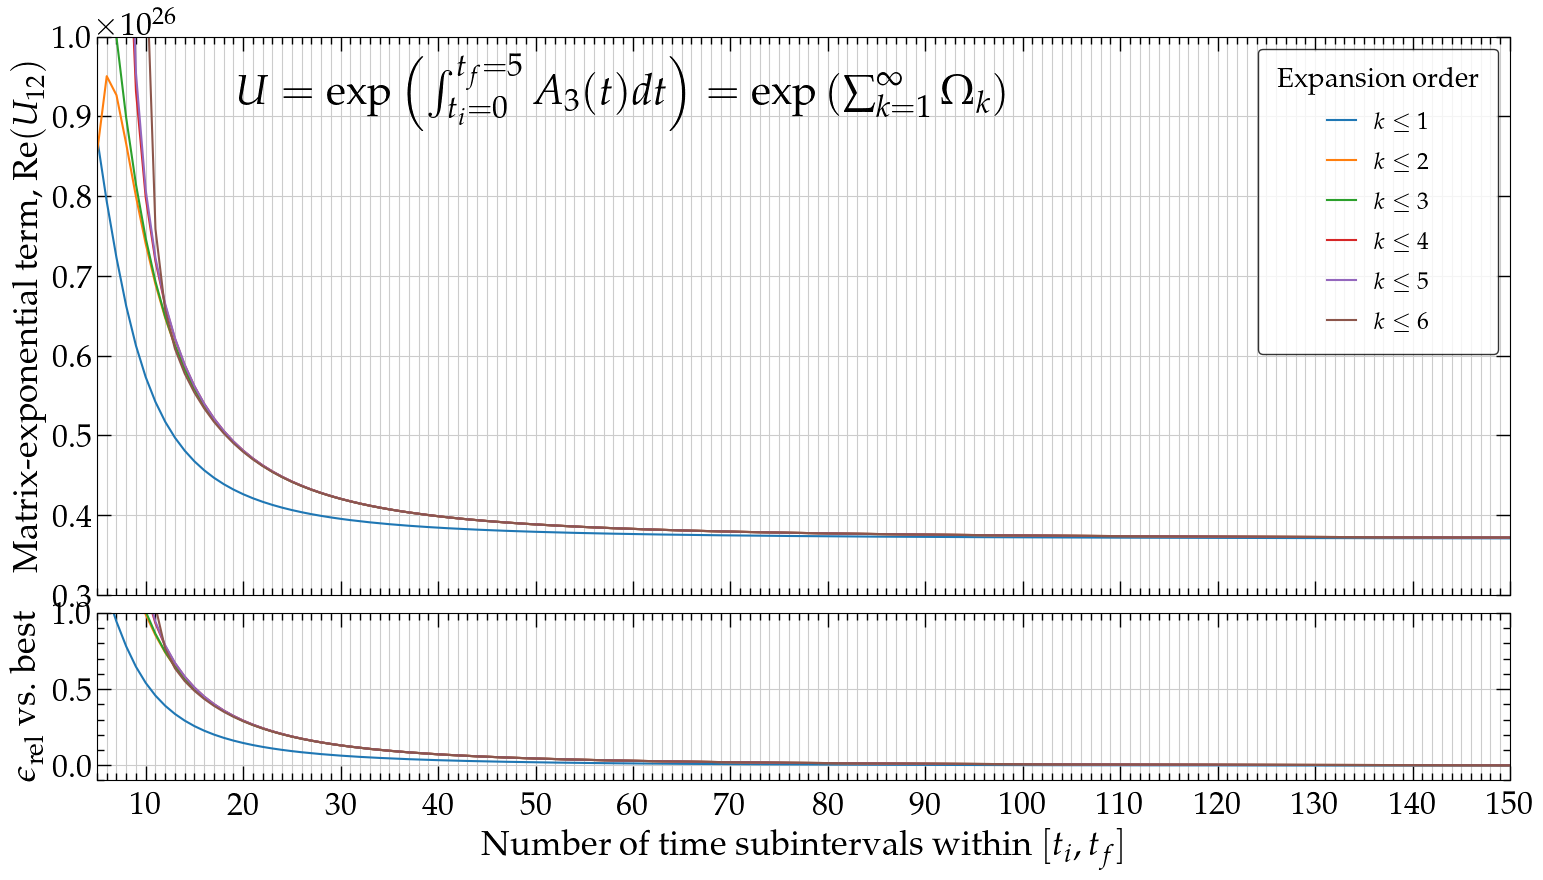

In [9]:
# Set run parameters
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
t_i, t_f = 0, 5
n_subintervals_min, n_subintervals_max = 5, 150

# Open the figure
heights, widths = [1.0, 0.3], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Compute the best case, to compare all others against
dt = (t_f-t_i)/n_subintervals_max # Width of each time subinterval
subintervals = np.array([[dt*i, dt*(i+1)] for i in range(n_subintervals_max)]) # Start and stop of each ubinterval
# Compute the matrix exponential in each subinterval
exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, subint[0], subint[1], n_tpts=10, order=order_max, 
                                                      integration_method='trapezoid') for subint in subintervals])
# Compute the time-ordered product of the matrix exponentials and save the selected matrix component
best = abs(np.linalg.multi_dot(exp_Omega_subintervals)[elem_sel_i][elem_sel_j].real)

# Now compute all other cases and plot them
for order in range(order_max):
    print("order = "+str(order+1))
    # Generate the data
    exp_Omega_elem_sel = []
    for n_subintervals in range(n_subintervals_min, n_subintervals_max+1): # Number of time subintervals into which we divide [t_i, t_f]
        # print(n_subintervals)
        dt = (t_f-t_i)/n_subintervals # Width of each time subinterval
        subintervals = np.array([[dt*i, dt*(i+1)] for i in range(n_subintervals)]) # Start and stop of each ubinterval
        # Compute the matrix exponential in each subinterval
        exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, subint[0], subint[1], n_tpts=10, order=order+1, 
                                                      integration_method='trapezoid') for subint in subintervals])
        # Compute the time-ordered product of the matrix exponentials and save the selected matrix component
        exp_Omega_elem_sel.append(abs(np.linalg.multi_dot(exp_Omega_subintervals)[elem_sel_i][elem_sel_j].real))
    # Plot the data
    ax[0].plot(range(n_subintervals_min, n_subintervals_max+1), exp_Omega_elem_sel, label=r'$k \leq~$'+str(order+1))
    rel_error = (exp_Omega_elem_sel-best)/best
    ax[1].plot(range(n_subintervals_min, n_subintervals_max+1), rel_error)

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Expansion order')

# Annotate
ax[0].annotate(r'$U = \exp \left( \int_{t_i=0}^{t_f=5} A_3(t) dt \right) = \exp \left( \sum_{k=1}^\infty \Omega_k \right) $', 
               xy = (0.10, 0.88),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(n_subintervals_min, n_subintervals_max)
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
# ax[0].set_yscale('log')
ax[0].set_ylim(3.e25, 1.e26)
ax[1].set_ylim(-0.1, 1)
ax[0].xaxis.set_ticklabels([])
# ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=100))
# ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=10))
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.5))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.1))
ax[0].set_ylabel(r'Matrix-exponential term, ${\rm Re} (U_{12})$')
ax[1].set_xlabel(r'Number of time subintervals within $[t_i, t_f]$')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}$ vs. best')

# Save plot
# filename = 'magnus_expansion_performance_vs_n_subintervals'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

So, in this case, about 100 subintervals are enough, regardless of the order of the Magnus expansion used.  This is because if there are many subintervals, then the corrections of higher-order terms within each subinterval are small.

Finally, let's see how this changes when we widen the interval $[t_i, t_f]$.

  n_subintervals = 3
  order = 1
  order = 2


/tmp/ipykernel_295365/3293579575.py:31: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi); raising the expansion order will not help there -- more (narrower) slabs are needed. If a target tolerance (rtol/atol) was requested, the adaptive refinement narrows the slabs automatically and this warning can be ignored. Shown once per session.
  exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, t_modifier*subint[0], t_modifier*subint[1],


  order = 3
  order = 4


  order = 5


  order = 6


...

  order = 2


  order = 3


  order = 4


  order = 5


  order = 6


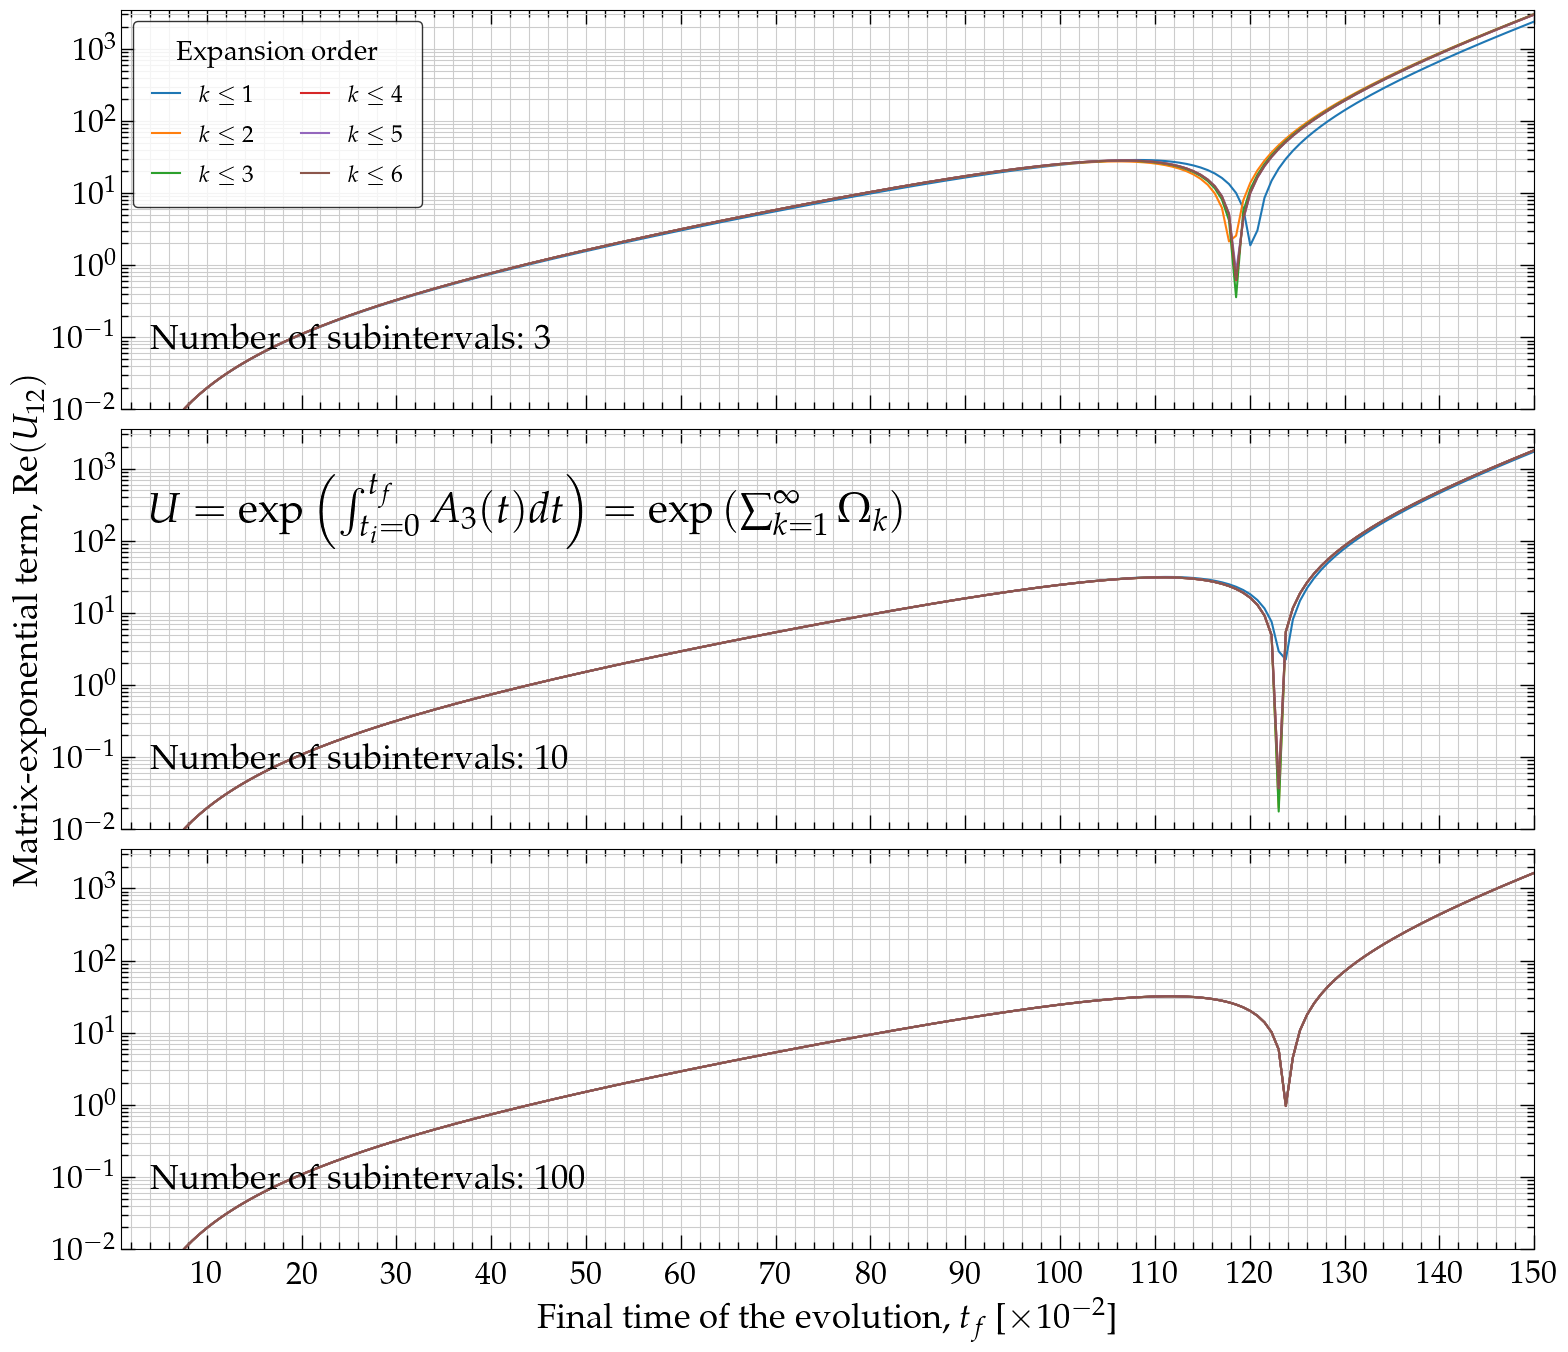

In [10]:
# Set run parameters
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
t_i = 1
t_f_max = 150
t_f_arr = np.linspace(t_i, t_f_max, 200)
t_modifier = 1.e-2

# Open the figure
heights, widths = [1.0, 1.0, 1.0], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=3, 
    gridspec_kw=gs_kw, 
    figsize=[18,15])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

n_subintervals_arr = [3,10,100]
for i, axx in enumerate(ax):
    n_subintervals = n_subintervals_arr[i]
    print("  n_subintervals = "+str(n_subintervals))
    for order in range(order_max):
        print("  order = "+str(order+1))
        # Generate the data
        exp_Omega_elem_sel = []
        for t_f in t_f_arr:
            dt = (t_f-t_i)/n_subintervals # Width of each time subinterval
            subintervals = np.array([[dt*i, dt*(i+1)] for i in range(n_subintervals)]) # Start and stop of each ubinterval
            # Compute the matrix exponential in each subinterval
            exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, t_modifier*subint[0], t_modifier*subint[1], 
                                                                       n_tpts=10, order=order+1, integration_method='trapezoid') 
                                               for subint in subintervals])
            # Compute the time-ordered product of the matrix exponentials and save the selected matrix component
            exp_Omega_elem_sel.append(abs(np.linalg.multi_dot(exp_Omega_subintervals)[elem_sel_i][elem_sel_j].real))
        # Plot the data
        axx.plot(t_f_arr, exp_Omega_elem_sel, label=r'$k \leq~$'+str(order+1))

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=2, title=r'Expansion order')

# Annotate
ax[1].annotate(r'$U = \exp \left( \int_{t_i=0}^{t_f} A_3(t) dt \right) = \exp \left( \sum_{k=1}^\infty \Omega_k \right) $', 
               xy = (0.02, 0.77),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(t_f_arr[0], t_f_arr[-1])
    axx.set_ylim(1.e-2, 3500)
    axx.set_yscale('log')
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=2))
    # axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=5))
    # axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='both', axis='y')
    if (i != 2):
        axx.xaxis.set_ticklabels([])
    else:
        axx.set_xlabel(r'Final time of the evolution, $t_f$ [$\times 10^{-2}$]')
    if (i == 1):
        axx.set_ylabel(r'Matrix-exponential term, ${\rm Re} (U_{12})$')
    axx.annotate(r'Number of subintervals: '+str(n_subintervals_arr[i]), 
                 xy = (0.02, 0.15),  xycoords='axes fraction',  ha='left', fontsize=25)

# Save plot
# filename = 'magnus_expansion_performance_vs_t_f'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

This shows that, as expected, the most accurate results are obtained using a high-order expansion and a large number of subintervals.  However, there is a trade-off between accuracy and speed.  The decision whether to favor one or the other, and to what extent will depend on the specific problem at hand.

## Where the coefficients come from: the Magnus terms to any order

Everything above used the expansion as a black box. The coefficients it runs on
are not arbitrary, though: they follow from a single recursion, and
`magnus.expansionterms` derives them symbolically at any order, in exact rational
arithmetic.

The recursion is

$$\Omega_n(t) = \sum_{j=1}^{n-1} \frac{B_j}{j!} \int_0^t S_n^{(j)}(s)\, ds ,
\qquad
S_n^{(1)} = [\Omega_{n-1}, A], \quad
S_n^{(j)} = \sum_{m=1}^{n-j} [\Omega_m, S_{n-m}^{(j-1)}] ,$$

with $B_j$ the Bernoulli numbers in the $B_1 = -1/2$ convention. Because
$B_j = 0$ for every odd $j \geq 3$, whole commutator groups drop out.

In [11]:
import magnus.expansionterms as et

# The Bernoulli numbers come back as exact fractions, not floats
{n: str(et.bernoulli(n)) for n in range(9)}

{0: '1',
 1: '-1/2',
 2: '1/6',
 3: '0',
 4: '-1/30',
 5: '0',
 6: '1/42',
 7: '0',
 8: '-1/30'}

The coefficient multiplying the $j$-th commutator group is $B_j/j!$. These are
precisely the constants the numerical core hard-codes as `F1`, `F2`, `F3`, `F4`:

In [12]:
import magnus.magnus as mg

for j, name in [(2, 'F1'), (4, 'F2'), (6, 'F3'), (8, 'F4')]:
    exact = et.bernoulli_factor(j)
    print(f"B_{j}/{j}! = {str(exact):>12s} = {float(exact):+.12e}   "
          f"mg.{name} = {getattr(mg, name):+.12e}")

B_2/2! =         1/12 = +8.333333333333e-02   mg.F1 = +8.333333333333e-02
B_4/4! =       -1/720 = -1.388888888889e-03   mg.F2 = -1.388888888889e-03
B_6/6! =      1/30240 = +3.306878306878e-05   mg.F3 = +3.306878306878e-05
B_8/8! =   -1/1209600 = -8.267195767196e-07   mg.F4 = -8.267195767196e-07


### Printing the expansion

`print_magnus_terms` writes out the integrand of each $\Omega_n$, one term per
line, with its exact coefficient:

In [13]:
et.print_magnus_terms(5)

Omega_1  (1 term)
    int A

Omega_2  (1 term)
    int -1/2 [Om_1, A]

Omega_3  (2 terms)
    int -1/2 [Om_2, A]
    int +1/12 [Om_1, [Om_1, A]]

Omega_4  (3 terms)
    int -1/2 [Om_3, A]
    int +1/12 [Om_1, [Om_2, A]]
    int +1/12 [Om_2, [Om_1, A]]

Omega_5  (5 terms)
    int -1/2 [Om_4, A]
    int +1/12 [Om_1, [Om_3, A]]
    int +1/12 [Om_2, [Om_2, A]]
    int +1/12 [Om_3, [Om_1, A]]
    int -1/720 [Om_1, [Om_1, [Om_1, [Om_1, A]]]]



### Beyond the implemented ceiling

The numerical core implements orders up to `MAGNUS_EXP_ORDER_MAX`, but the
generator has no ceiling of its own — useful for seeing how fast the expansion
grows before committing to an order. Every term turns out to be a right-nested
chain $[\Omega_{m_1},[\Omega_{m_2},\ldots[\Omega_{m_j}, A]]]$ whose indices sum
to $n-1$, so the $j$-th group has $\binom{n-2}{j-1}$ terms.

In [14]:
print(f"implemented up to order {mg.MAGNUS_EXP_ORDER_MAX}\n")
print(f"{'order':>6s} {'terms':>7s}")
for n in range(1, 15):
    marker = '  <- ceiling' if n == mg.MAGNUS_EXP_ORDER_MAX else ''
    print(f"{n:6d} {et.count_terms(n):7d}{marker}")

implemented up to order 10

 order   terms
     1       1
     2       1
     3       2
     4       3
     5       5
     6       9
     7      17
     8      33
     9      65
    10     129  <- ceiling
    11     257
    12     513
    13    1025
    14    2049


The count roughly doubles per order, and so does the work per slab. That is the
trade behind the cost warning: order 7 costs about 2.7x order 6 on the same grid,
order 10 about 17x. Higher order does converge faster in the slab width, but
narrowing the slabs at order 4 or 6 often reaches a given accuracy for less total
work — and beyond the series' convergence radius, $\int\lVert A\rVert\,dt < \pi$,
no order helps at all.

One term of order 12, which the numerical core does not implement but the
generator will still hand you:

In [15]:
terms_12 = et.omega_terms(12)
print(f"Omega_12 has {len(terms_12)} terms. The last one is")
print("   int " + et.format_term(terms_12[-1]))

Omega_12 has 513 terms. The last one is
   int +1/47900160 [Om_2, [Om_1, [Om_1, [Om_1, [Om_1, [Om_1, [Om_1, [Om_1, [Om_1, [Om_1, A]]]]]]]]]]
